## Cell 1 - Cài Thư Viện


In [ ]:
# ==============================================================
# CELL 1: IMPORTS + GPU / LOCAL DEVICE SETUP
# ==============================================================
from pathlib import Path
import os
import sys

# Doi thanh False neu muon cho phep fallback CPU.
REQUIRE_GPU = True
GPU_ID = "0"
os.environ.setdefault("CUDA_VISIBLE_DEVICES", GPU_ID)

import torch


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / ".env").exists() or (candidate / ".env.example").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")
print(f"Python      : {sys.executable}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torch CUDA  : {torch.version.cuda}")
print(f"CUDA visible: {os.getenv('CUDA_VISIBLE_DEVICES')}")
print(f"CUDA ready  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    torch.cuda.set_device(0)
    DEVICE = torch.device("cuda:0")
    print(f"GPU device  : {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
else:
    if REQUIRE_GPU:
        msg = (
            "PyTorch khong nhan GPU/CUDA. Cai PyTorch CUDA trong dung env dang chay notebook. "
            "Vi du: conda activate mining; "
            "pip uninstall torch torchvision torchaudio -y; "
            "pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121; "
            "sau do restart kernel."
        )
        raise RuntimeError(msg)
    DEVICE = torch.device("cpu")

print(f"Device      : {DEVICE}")

Project root: c:\Users\Admin\Documents\project\BigData_Mining_Project-main\BigData_Mining_Project-main
Python      : c:\Users\Admin\anaconda3\envs\mining\python.exe
PyTorch     : 2.5.1+cu121
Torch CUDA  : 12.1
CUDA visible: 0
CUDA ready  : True
GPU device  : NVIDIA RTX A2000 8GB Laptop GPU
Device      : cuda:0


## Cell 2 - Kết nối Snowflake & Load data


In [ ]:
import os
os.environ["SNOWFLAKE_ACCOUNT"] = "ms14138.ap-southeast-1"

In [ ]:
# ==============================================================
# CELL 2 + 3: TẢI DỮ LIỆU VÀ TIỀN XỬ LÝ
# ============================================================== 
import os, math, warnings, time
import numpy as np
import pandas as pd
import snowflake.connector
from dotenv import load_dotenv
from IPython.display import display

warnings.filterwarnings("ignore")

load_dotenv(PROJECT_ROOT / ".env", override=True)

required_env = [
    "SNOWFLAKE_USER",
    "SNOWFLAKE_PASSWORD",
    "SNOWFLAKE_ACCOUNT",
    "SNOWFLAKE_WAREHOUSE",
    "SNOWFLAKE_DATABASE",
    "SNOWFLAKE_SCHEMA",
]
missing = [name for name in required_env if not os.getenv(name)]
if missing:
    raise EnvironmentError(
        "Missing environment variables: "
        + ", ".join(missing)
        + ". Fill .env before running locally."
    )

conn_config = {
    "user": os.environ["SNOWFLAKE_USER"],
    "password": os.environ["SNOWFLAKE_PASSWORD"],
    "account": os.environ["SNOWFLAKE_ACCOUNT"],
    "warehouse": os.environ["SNOWFLAKE_WAREHOUSE"],
    "database": os.environ.get("SNOWFLAKE_DATABASE", "BIGDATA_DB"),
    "schema": os.environ.get("SNOWFLAKE_SCHEMA", "STAGING"),
    "autocommit": True,
}
if os.getenv("SNOWFLAKE_ROLE"):
    conn_config["role"] = os.environ["SNOWFLAKE_ROLE"]

SOURCE_TABLE = "BIGDATA_DB.STAGING.USER_PORTFOLIOS"
TOKEN_CATEGORY_TABLE = "BIGDATA_DB.STAGING.TOKEN_CATEGORY"
CATEGORY_WEIGHT = 0.20  # 0.0 = chi LightGCN, 0.2 = them category rerank nhe

print(f"Loading {SOURCE_TABLE} + {TOKEN_CATEGORY_TABLE}...")
t0 = time.time()

sql = f'''
SELECT
    LOWER(CAST(p.USER_ID AS VARCHAR)) AS user_id,
    LOWER(CAST(p.TOKEN_ID AS VARCHAR)) AS token_id,
    CAST(p.TX_COUNT AS FLOAT) AS tx_count,
    COALESCE(UPPER(c.SYMBOL), 'UNKNOWN') AS symbol,
    COALESCE(UPPER(c.CATEGORY), 'UNKNOWN') AS category
FROM {SOURCE_TABLE} p
LEFT JOIN {TOKEN_CATEGORY_TABLE} c
    ON CAST(p.TOKEN_ID AS INT) = CAST(c.TOKEN_ID AS INT)
WHERE p.USER_ID IS NOT NULL
  AND p.TOKEN_ID IS NOT NULL
  AND p.TX_COUNT > 0
'''

conn = snowflake.connector.connect(**conn_config)
cur = conn.cursor()
try:
    cur.execute(f"USE WAREHOUSE {os.environ['SNOWFLAKE_WAREHOUSE']}")
    cur.execute(sql)
    cols = [d[0].lower() for d in cur.description]
    df = pd.DataFrame(cur.fetchall(), columns=cols)
finally:
    cur.close()
    conn.close()

print(f"Tai du lieu xong trong {time.time() - t0:.1f}s. So dong ban dau: {len(df):,}")

# 1. Gom nhom tx_count vi 1 user-token co the xuat hien nhieu dong.
df["tx_count"] = pd.to_numeric(df["tx_count"], errors="coerce").fillna(0.0)
df["symbol"] = df["symbol"].fillna("UNKNOWN").astype(str).str.upper()
df["category"] = df["category"].fillna("UNKNOWN").astype(str).str.upper()
df = (
    df.groupby(["user_id", "token_id"], as_index=False)
    .agg(
        tx_count=("tx_count", "sum"),
        symbol=("symbol", "first"),
        category=("category", "first"),
    )
)

# 2. Tính edge_weight chuẩn hóa về [0,1]
def scale_0_1(series):
    max_value = series.max()
    if pd.isna(max_value) or max_value <= 0:
        return series * 0.0
    return series / max_value

df["edge_weight"] = scale_0_1(np.log1p(df["tx_count"].clip(lower=0))).astype(np.float32)

# 3. Lọc dữ liệu.
MIN_USER_TOKENS = 3
MIN_TOKEN_HOLDERS = 1
user_counts = df.groupby("user_id")["token_id"].transform("nunique")
token_counts = df.groupby("token_id")["user_id"].transform("nunique")
df = df[(user_counts >= MIN_USER_TOKENS) & (token_counts >= MIN_TOKEN_HOLDERS)].copy()

# 4. Encode ID sang dạng số nguyên cho GNN.
user_list = sorted(df["user_id"].unique())
token_list = sorted(df["token_id"].unique())
user2idx = {u: i for i, u in enumerate(user_list)}
token2idx = {t: i for i, t in enumerate(token_list)}
idx2user = dict(enumerate(user_list))
idx2token = dict(enumerate(token_list))

df["u_idx"] = df["user_id"].map(user2idx)
df["t_idx"] = df["token_id"].map(token2idx)

# Metadata map cho từng token index.
idx2symbol = (
    df.drop_duplicates("t_idx")
    .set_index("t_idx")["symbol"]
    .to_dict()
)
idx2category = (
    df.drop_duplicates("t_idx")
    .set_index("t_idx")["category"]
    .to_dict()
)

N_USERS = len(user_list)
N_TOKENS = len(token_list)

print(f"Sau khi loc: {len(df):,} interactions | {N_USERS:,} users | {N_TOKENS:,} tokens")
print("Category distribution:")
print(df.drop_duplicates("token_id")["category"].value_counts())
display(df[["user_id", "token_id", "symbol", "category", "tx_count", "edge_weight"]].head(5))


Loading BIGDATA_DB.STAGING.USER_PORTFOLIOS + BIGDATA_DB.STAGING.TOKEN_CATEGORY...
Tai du lieu xong trong 14.5s. So dong ban dau: 2,274,180
Sau khi loc: 2,009,514 interactions | 464,423 users | 381 tokens
Category distribution:
category
UNKNOWN    381
Name: count, dtype: int64


,user_id,token_id,symbol,category,tx_count,edge_weight
0,10,130149,WETH,UNKNOWN,1.0,0.075308
1,10,147692,USDT,UNKNOWN,19.0,0.325474
2,10,26553,AST,UNKNOWN,3.0,0.150615
3,10,31100,YFED,UNKNOWN,1.0,0.075308
4,10,97321,REQ,UNKNOWN,13.0,0.286722


## Cell 3 - Leave-One-Out Split


In [ ]:
# ==============================================================
# CELL 3: CHIA TẬP TEST (HOLD-OUT 1 TOKEN Y HỆT ALS)
# ==============================================================
import random
from collections import defaultdict
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)
HOLDOUT_N = 1

train_rows = []
test_rows = []
loo_gt = defaultdict(list)

for u, grp in df.groupby('u_idx'):
    # Cần chừa lại ít nhất 1 token trong tập Train
    n_holdout = min(HOLDOUT_N, len(grp) - 1)
    if n_holdout > 0:
        chosen_indices = rng.choice(grp.index.to_numpy(), size=n_holdout, replace=False)
        test_rows.extend(chosen_indices.tolist())
        train_rows.extend([i for i in grp.index if i not in chosen_indices])
        # Lưu đáp án cho tập Test
        loo_gt[u].extend(df.loc[chosen_indices, 't_idx'].tolist())
    else:
        train_rows.extend(grp.index.tolist())

df_train = df.loc[train_rows].copy().reset_index(drop=True)

print(f"Holdout tokens per user: {HOLDOUT_N}")
print(f"Train interactions: {len(df_train):,}")
print(f"Test interactions (có đáp án): {len(test_rows):,}")
print(f"Test users: {len(loo_gt):,}")

# Ghi nhớ các token đã có trong tập Train để đánh giá (không gợi ý lại đồ cũ)
user_seen = df_train.groupby('u_idx')['t_idx'].apply(set).to_dict()


Holdout tokens per user: 1
Train interactions: 1,545,091
Test interactions (có đáp án): 464,423
Test users: 464,423


## Cell 3 - Thống Kê Dữ Liệu

=== 1. THỐNG KÊ MÔ TẢ CÁC CỘT DỮ LIỆU ===


,tx_count,edge_weight
count,2.009514e+06,2.009514e+06
mean,1.228119e+01,1.846464e-01
std,1.054462e+02,1.104969e-01
min,1.000000e+00,7.530753e-02
25%,1.000000e+00,7.530753e-02
50%,4.000000e+00,1.748587e-01
75%,1.200000e+01,2.786710e-01
max,9.938000e+03,1.000000e+00



=== 2. TOP 10 TOKEN PHỔ BIẾN NHẤT (THEO SỐ LƯỢNG VÍ) ===


,token_id,holder_count
79,130149,288159
125,148342,195816
280,55220,164802
74,126457,98293
219,31100,97675
262,50339,51575
200,23420,35489
276,54168,22499
296,61519,18410
24,109098,16932



=== 3. TRỰC QUAN HÓA PHÂN PHỐI DỮ LIỆU ===


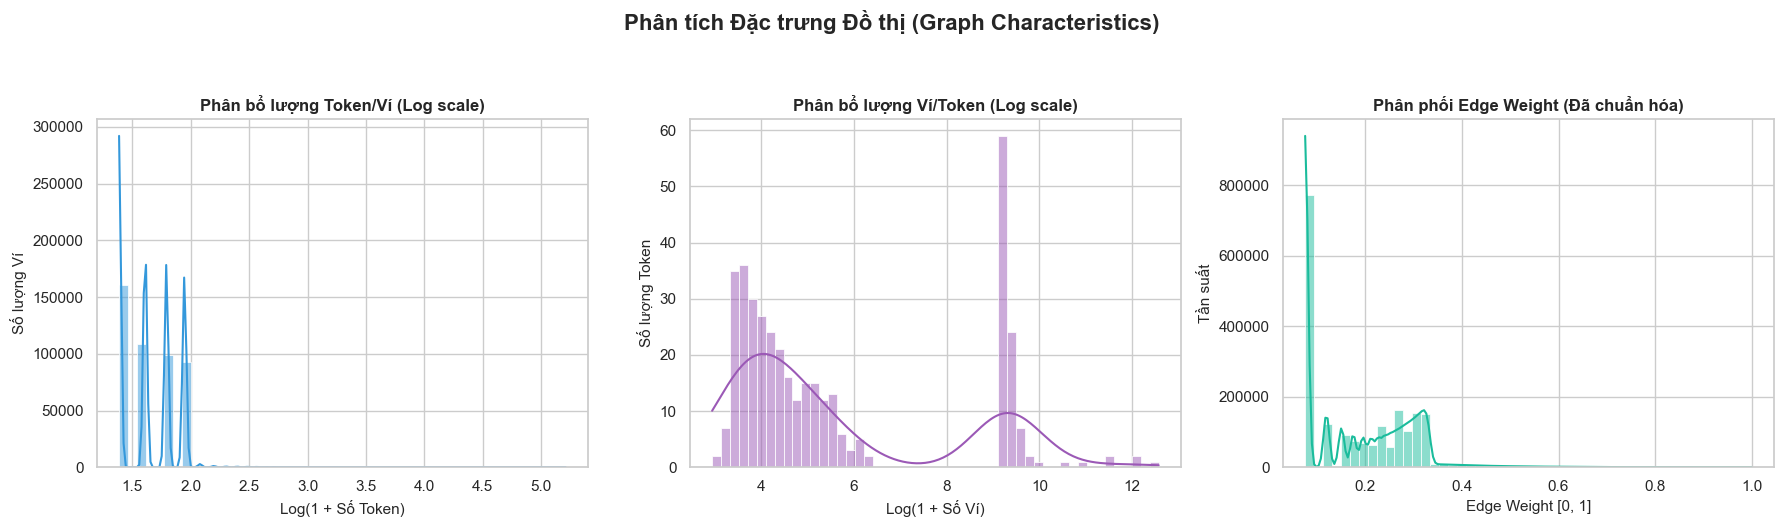


💡 ĐÁNH GIÁ ĐỘ THƯA (SPARSITY):
- Ma trận GNN có kích thước: 464,423 Users x 381 Tokens
- Tổng số tương tác thực tế: 2,009,514
- Độ thưa thớt (Sparsity): 98.8643% (Càng gần 100% mô hình càng khó học)


In [ ]:
# ==============================================================
# Cell 4:THỐNG KÊ, PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU (EDA)
# ==============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

# Cài đặt style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

print("=== 1. THỐNG KÊ MÔ TẢ CÁC CỘT DỮ LIỆU ===")
# Hiển thị thống kê các cột số: tx_count và edge_weight
display(df[['tx_count', 'edge_weight']].describe())

print("\n=== 2. TOP 10 TOKEN PHỔ BIẾN NHẤT (THEO SỐ LƯỢNG VÍ) ===")
top_tokens = df.groupby('token_id')['user_id'].count().reset_index(name='holder_count')
top_tokens = top_tokens.sort_values(by='holder_count', ascending=False).head(10)
display(top_tokens)

print("\n=== 3. TRỰC QUAN HÓA PHÂN PHỐI DỮ LIỆU ===")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân tích Đặc trưng Đồ thị (Graph Characteristics)', fontsize=16, fontweight='bold', y=1.05)

# Biểu đồ 1: Phân bố số lượng Token mà mỗi User nắm giữ (User Degree)
tokens_per_user = df.groupby('user_id')['token_id'].count()
sns.histplot(np.log1p(tokens_per_user), bins=50, ax=axes[0], color='#3498db', kde=True)
axes[0].set_title('Phân bổ lượng Token/Ví (Log scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log(1 + Số Token)', fontsize=11)
axes[0].set_ylabel('Số lượng Ví', fontsize=11)

# Biểu đồ 2: Phân bố số lượng User nắm giữ mỗi Token (Token Popularity / Long-tail)
users_per_token = df.groupby('token_id')['user_id'].count()
sns.histplot(np.log1p(users_per_token), bins=50, ax=axes[1], color='#9b59b6', kde=True)
axes[1].set_title('Phân bổ lượng Ví/Token (Log scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(1 + Số Ví)', fontsize=11)
axes[1].set_ylabel('Số lượng Token', fontsize=11)

# Biểu đồ 3: Phân phối Trọng số Cạnh (Edge Weight)
sns.histplot(df['edge_weight'], bins=50, ax=axes[2], color='#1abc9c', kde=True)
axes[2].set_title('Phân phối Edge Weight (Đã chuẩn hóa)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Edge Weight [0, 1]', fontsize=11)
axes[2].set_ylabel('Tần suất', fontsize=11)

plt.tight_layout()
plt.show()

# Đánh giá tính thưa thớt (Sparsity) của ma trận
n_u = df['user_id'].nunique()
n_t = df['token_id'].nunique()
sparsity = (1 - len(df) / (n_u * n_t)) * 100
print(f"\n💡 ĐÁNH GIÁ ĐỘ THƯA (SPARSITY):")
print(f"- Ma trận GNN có kích thước: {n_u:,} Users x {n_t:,} Tokens")
print(f"- Tổng số tương tác thực tế: {len(df):,}")
print(f"- Độ thưa thớt (Sparsity): {sparsity:.4f}% (Càng gần 100% mô hình càng khó học)")

## Cell 5 - LightGCN Model


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LightGCN(nn.Module):
    def __init__(self, n_users, n_tokens, embed_dim=64, n_layers=3):
        super().__init__()
        self.n_users  = n_users
        self.n_tokens = n_tokens
        self.n_layers = n_layers
        self.user_emb  = nn.Embedding(n_users,  embed_dim)
        self.token_emb = nn.Embedding(n_tokens, embed_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.token_emb.weight)

    def build_adj(self, edge_u, edge_t, edge_w):
        N   = self.n_users + self.n_tokens
        row = torch.cat([edge_u, edge_t + self.n_users])
        col = torch.cat([edge_t + self.n_users, edge_u])
        val = torch.cat([edge_w, edge_w])
        # D^{-0.5} A D^{-0.5} normalization
        deg = torch.zeros(N, device=edge_u.device)
        deg.scatter_add_(0, row, val)
        deg = deg.clamp(min=1).pow(-0.5)
        val_norm = deg[row] * val * deg[col]
        idx = torch.stack([row, col], dim=0)
        self.adj = torch.sparse_coo_tensor(idx, val_norm, (N,N)).coalesce()
        return self.adj

    def forward(self):
        x = torch.cat([self.user_emb.weight, self.token_emb.weight], dim=0)
        out = [x]
        for _ in range(self.n_layers):
            x = torch.sparse.mm(self.adj, x)
            out.append(x)
        out = torch.stack(out, dim=1).mean(dim=1)
        return out[:self.n_users], out[self.n_users:]

    def bpr_loss(self, U, V, users, pos_items, neg_items, reg=1e-4):
        u  = U[users]; pi = V[pos_items]; ni = V[neg_items]
        loss = -F.logsigmoid((u*pi).sum(1) - (u*ni).sum(1)).mean()
        l2   = (u.norm(2).pow(2)+pi.norm(2).pow(2)+ni.norm(2).pow(2))/len(users)
        return loss + reg*l2

print('LightGCN defined OK')


LightGCN defined OK


## Cell 6 - Chuẩn bị Graph & Train


In [ ]:
# ==========================================
# CELL 6: CHUẨN BỊ GRAPH & TRAIN TRÊN GPU
# ==========================================
if DEVICE.type != "cuda":
    raise RuntimeError("Cell nay dang duoc cau hinh de train bang GPU, nhung DEVICE khong phai cuda.")

edge_u = torch.as_tensor(df_train["u_idx"].to_numpy(), dtype=torch.long, device=DEVICE)
edge_t = torch.as_tensor(df_train["t_idx"].to_numpy(), dtype=torch.long, device=DEVICE)
edge_w = torch.as_tensor(df_train["edge_weight"].to_numpy(), dtype=torch.float32, device=DEVICE)

EMBED_DIM = 128
N_LAYERS = 2
N_EPOCHS = 20 
BATCH_SIZE = 8192
LR = 1e-3
BPR_REG = 1e-3

model = LightGCN(N_USERS, N_TOKENS, EMBED_DIM, N_LAYERS).to(DEVICE)

print("Xay dung Adjacency Matrix tren GPU...")
t0 = time.time()
adj = model.build_adj(edge_u, edge_t, edge_w)
print(f"Build adj xong trong {time.time() - t0:.1f}s | device={adj.device} | nnz={adj._nnz():,}")

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train_u_tensor = torch.as_tensor(df_train["u_idx"].to_numpy(), dtype=torch.long, device=DEVICE)
train_t_tensor = torch.as_tensor(df_train["t_idx"].to_numpy(), dtype=torch.long, device=DEVICE)
n_train = train_u_tensor.numel()

print(f"Train {N_EPOCHS} epochs, batch={BATCH_SIZE:,}, device={DEVICE}")
print("-" * 50)
history = []

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    t_ep = time.time()
    perm = torch.randperm(n_train, device=DEVICE)
    total_loss = 0.0
    n_batches = 0

    for start in range(0, n_train, BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        users = train_u_tensor[idx]
        pos_items = train_t_tensor[idx]
        neg_items = torch.randint(0, N_TOKENS, (idx.numel(),), device=DEVICE)

        U, V = model()
        loss = model.bpr_loss(U, V, users, pos_items, neg_items, reg=BPR_REG)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.detach().cpu())
        n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        if DEVICE.type == "cuda":
            mem_gb = torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 3)
            torch.cuda.reset_peak_memory_stats(DEVICE)
            print(f"  Epoch {epoch:3d}/{N_EPOCHS}  loss={avg_loss:.4f}  time={time.time()-t_ep:.1f}s  peak_mem={mem_gb:.2f}GB")
        else:
            print(f"  Epoch {epoch:3d}/{N_EPOCHS}  loss={avg_loss:.4f}  time={time.time()-t_ep:.1f}s")

print("Train xong!")


Xay dung Adjacency Matrix tren GPU...
Build adj xong trong 0.1s | device=cuda:0 | nnz=3,090,182
Train 20 epochs, batch=8,192, device=cuda:0
--------------------------------------------------
  Epoch   1/20  loss=0.4633  time=64.9s  peak_mem=2.78GB
  Epoch  10/20  loss=0.2362  time=64.8s  peak_mem=2.78GB
  Epoch  20/20  loss=0.1776  time=64.8s  peak_mem=2.78GB
Train xong!


## Cell 7 - Đánh giá: HitRate / Recall / NDCG 


[eval] Extract embeddings from LightGCN...
[eval] USER_EMB=(464423, 128), ITEM_EMB=(381, 128)
[eval] Build category profile...
[eval] Category profile=(464423, 1)
[eval] Full-catalog users=464,423, batch=2,000
[eval] Full-catalog progress 0/464,423
[eval] Full-catalog progress 20,000/464,423
[eval] Full-catalog progress 40,000/464,423
[eval] Full-catalog progress 60,000/464,423
[eval] Full-catalog progress 80,000/464,423
[eval] Full-catalog progress 100,000/464,423
[eval] Full-catalog progress 120,000/464,423
[eval] Full-catalog progress 140,000/464,423
[eval] Full-catalog progress 160,000/464,423
[eval] Full-catalog progress 180,000/464,423
[eval] Full-catalog progress 200,000/464,423
[eval] Full-catalog progress 220,000/464,423
[eval] Full-catalog progress 240,000/464,423
[eval] Full-catalog progress 260,000/464,423
[eval] Full-catalog progress 280,000/464,423
[eval] Full-catalog progress 300,000/464,423
[eval] Full-catalog progress 320,000/464,423
[eval] Full-catalog progress 340,00

,eval_type,k,metric,value
0,full_catalog,5,HitRate,0.494560
1,full_catalog,5,Recall,0.494560
2,full_catalog,5,NDCG,0.365197
3,full_catalog,10,HitRate,0.548050
4,full_catalog,10,Recall,0.548050
5,full_catalog,10,NDCG,0.382587
6,full_catalog,20,HitRate,0.611180
7,full_catalog,20,Recall,0.611180
8,full_catalog,20,NDCG,0.398436


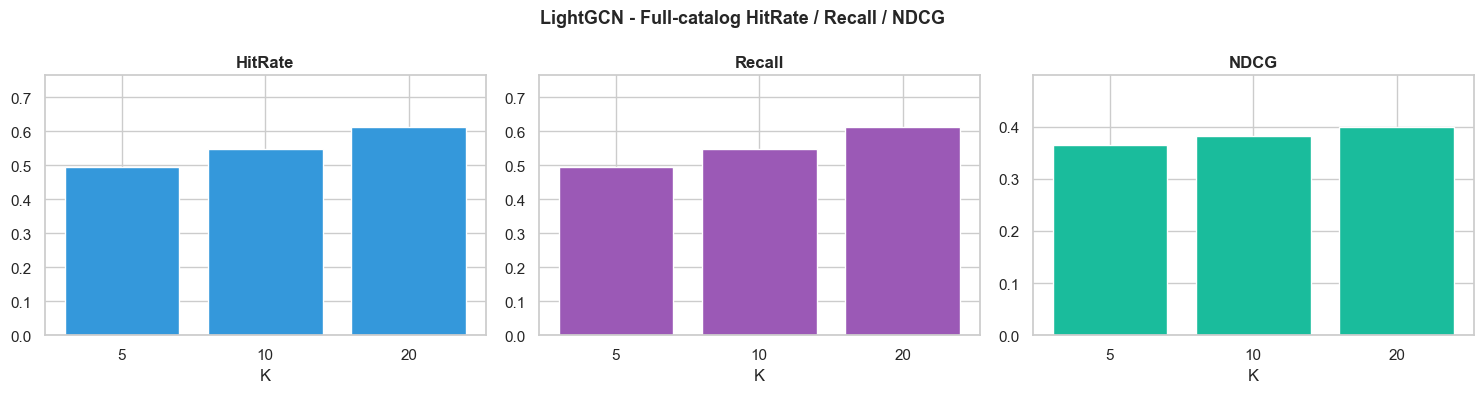

In [ ]:
# ==========================================
# CELL 7: ĐÁNH GIÁ HOLDOUT - HITRATE / RECALL / NDCG
# ==========================================
import gc
import matplotlib.pyplot as plt

KS = [5, 10, 20]
EVAL_BATCH_SIZE = 2000

print("[eval] Extract embeddings from LightGCN...", flush=True)
model.eval()
with torch.inference_mode():
    user_emb_t, item_emb_t = model()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    USER_EMB = user_emb_t.detach().to("cpu", dtype=torch.float32).numpy()
    ITEM_EMB = item_emb_t.detach().to("cpu", dtype=torch.float32).numpy()

del user_emb_t, item_emb_t
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()

print(f"[eval] USER_EMB={USER_EMB.shape}, ITEM_EMB={ITEM_EMB.shape}", flush=True)


def build_category_profile(train_data):
    categories = sorted(df["category"].fillna("UNKNOWN").astype(str).unique())
    cat2idx = {cat: idx for idx, cat in enumerate(categories)}
    unknown_idx = cat2idx.get("UNKNOWN", 0)

    profile = np.zeros((N_USERS, len(categories)), dtype=np.float32)
    train_cats = train_data[["u_idx", "category", "edge_weight"]].copy()
    train_cats["category"] = train_cats["category"].fillna("UNKNOWN").astype(str)
    grouped = train_cats.groupby(["u_idx", "category"], as_index=False)["edge_weight"].sum()

    u_arr = grouped["u_idx"].to_numpy(dtype=np.int64)
    c_arr = grouped["category"].map(cat2idx).fillna(unknown_idx).to_numpy(dtype=np.int64)
    w_arr = grouped["edge_weight"].to_numpy(dtype=np.float32)
    profile[u_arr, c_arr] = w_arr

    row_sum = profile.sum(axis=1, keepdims=True)
    nonzero = row_sum[:, 0] > 0
    profile[nonzero] = profile[nonzero] / row_sum[nonzero]

    token_cat_idx = np.array([
        cat2idx.get(str(idx2category.get(i, "UNKNOWN")), unknown_idx)
        for i in range(N_TOKENS)
    ], dtype=np.int64)
    return profile, token_cat_idx


def normalize_score_matrix(scores):
    scores = scores.astype(np.float32, copy=False)
    row_min = scores.min(axis=1, keepdims=True)
    row_max = scores.max(axis=1, keepdims=True)
    denom = np.where((row_max - row_min) > 1e-12, row_max - row_min, 1.0)
    return ((scores - row_min) / denom).astype(np.float32, copy=False)


def ndcg_at_k(recommended_items, actual_items, k):
    actual_items = set(actual_items)
    if not actual_items:
        return 0.0

    dcg = 0.0
    for rank, item in enumerate(recommended_items[:k], start=1):
        if item in actual_items:
            dcg += 1.0 / np.log2(rank + 1.0)

    ideal_hits = min(len(actual_items), k)
    idcg = sum(1.0 / np.log2(rank + 1.0) for rank in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


print("[eval] Build category profile...", flush=True)
CATEGORY_PROFILE, TOKEN_CAT_IDX = build_category_profile(df_train)
print(f"[eval] Category profile={CATEGORY_PROFILE.shape}", flush=True)


def score_full_catalog(user_batch):
    user_vec = USER_EMB[user_batch].astype(np.float32, copy=False)
    raw_scores = user_vec @ ITEM_EMB.T
    scores = normalize_score_matrix(raw_scores)

    if CATEGORY_WEIGHT > 0:
        category_scores = CATEGORY_PROFILE[user_batch][:, TOKEN_CAT_IDX]
        scores = (1.0 - CATEGORY_WEIGHT) * scores + CATEGORY_WEIGHT * category_scores
        scores = scores.astype(np.float32, copy=False)

    return scores


def evaluate_full_catalog(test_gt, user_seen, k_list=KS):
    uids = np.array(sorted(test_gt.keys()), dtype=np.int64)
    max_k = max(k_list)
    res = {k: {"hit": [], "recall": [], "ndcg": []} for k in k_list}

    print(f"[eval] Full-catalog users={len(uids):,}, batch={EVAL_BATCH_SIZE:,}", flush=True)
    for batch_start in range(0, len(uids), EVAL_BATCH_SIZE):
        if batch_start % (EVAL_BATCH_SIZE * 10) == 0:
            print(f"[eval] Full-catalog progress {batch_start:,}/{len(uids):,}", flush=True)

        user_batch = uids[batch_start:batch_start + EVAL_BATCH_SIZE]
        scores = score_full_catalog(user_batch)

        # Khong goi y lai token da co trong tap train.
        for local_pos, u in enumerate(user_batch):
            for seen_i in user_seen.get(int(u), set()):
                if seen_i < N_TOKENS:
                    scores[local_pos, seen_i] = -np.inf

        kth = min(max_k, N_TOKENS) - 1
        top = np.argpartition(-scores, kth, axis=1)[:, :max_k]
        top_scores = np.take_along_axis(scores, top, axis=1)
        order = np.argsort(-top_scores, axis=1)
        top = np.take_along_axis(top, order, axis=1)

        for local_pos, u in enumerate(user_batch):
            gt_items = set(test_gt[int(u)])
            for k in k_list:
                topk = top[local_pos, :k].tolist()
                hit_count = len(set(topk) & gt_items)
                res[k]["hit"].append(1 if hit_count > 0 else 0)
                res[k]["recall"].append(hit_count / len(gt_items))
                res[k]["ndcg"].append(ndcg_at_k(topk, gt_items, k))

        del scores, top, top_scores, order
        gc.collect()

    rows = []
    metrics = {"n_eval": len(uids)}
    for k in k_list:
        hit_rate = float(np.mean(res[k]["hit"])) if res[k]["hit"] else 0.0
        recall = float(np.mean(res[k]["recall"])) if res[k]["recall"] else 0.0
        ndcg = float(np.mean(res[k]["ndcg"])) if res[k]["ndcg"] else 0.0
        metrics[f"HitRate@{k}"] = round(hit_rate, 4)
        metrics[f"Recall@{k}"] = round(recall, 4)
        metrics[f"NDCG@{k}"] = round(ndcg, 4)
        rows.extend([
            {"eval_type": "full_catalog", "k": k, "metric": "HitRate", "value": hit_rate},
            {"eval_type": "full_catalog", "k": k, "metric": "Recall", "value": recall},
            {"eval_type": "full_catalog", "k": k, "metric": "NDCG", "value": ndcg},
        ])

    return metrics, pd.DataFrame(rows)


metrics, metrics_df = evaluate_full_catalog(loo_gt, user_seen, KS)

print("=" * 56)
print(f"KET QUA DANH GIA - LightGCN + Category Rerank (weight={CATEGORY_WEIGHT})")
print(f"Full-catalog users: {metrics['n_eval']:,}")
print("=" * 56)
for k in KS:
    print(f"Full-catalog HitRate@{k}: {metrics[f'HitRate@{k}']:.4f}")
    print(f"Full-catalog Recall@{k}:  {metrics[f'Recall@{k}']:.4f}")
    print(f"Full-catalog NDCG@{k}:    {metrics[f'NDCG@{k}']:.4f}")
print("=" * 56)

display(metrics_df)

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("LightGCN - Full-catalog HitRate / Recall / NDCG", fontsize=13, fontweight="bold")
for ax, metric_name, color in zip(axes, ["HitRate", "Recall", "NDCG"], ["#3498db", "#9b59b6", "#1abc9c"]):
    plot_df = metrics_df[metrics_df["metric"] == metric_name].sort_values("k")
    ax.bar(plot_df["k"].astype(str), plot_df["value"], color=color)
    ax.set_title(metric_name, fontweight="bold")
    ax.set_xlabel("K")
    ax.set_ylim(0, max(0.01, plot_df["value"].max() * 1.25))
plt.tight_layout()
plt.show()


## Cell 8 - Lưu Factors cho LSH


In [ ]:
# ==========================================
# CELL 8: LƯU EMBEDDING / LSH INPUTS LOCAL + SNOWFLAKE - 2 FACTOR TABLES ONLY
# ==========================================

import os
import gc
import time
import numpy as np
import pandas as pd
from pathlib import Path

from dotenv import load_dotenv
import snowflake.connector


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / ".env").exists() or (candidate / "outputs").exists() or (candidate / "mining-algorithms").exists():
            return candidate
    return Path.cwd()


def to_numpy_float32(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy().astype(np.float32, copy=False)
    return np.asarray(x, dtype=np.float32)


def sql_quote(value):
    return "'" + str(value).replace("'", "''") + "'"


def put_uri(path):
    return "file://" + path.resolve().as_posix()


PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / ".env")

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "lsh_inputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_USER_FACTORS = True
UPLOAD_TO_SNOWFLAKE = True
USER_CHUNK_SIZE = 50_000

SF_STAGE = os.getenv("SNOWFLAKE_LSH_STAGE", "LSH_INPUTS_STAGE")
SF_FILE_FORMAT = os.getenv("SNOWFLAKE_LSH_FILE_FORMAT", "LSH_INPUTS_CSV_FORMAT")

TABLE_USER_FACTORS = os.getenv("SNOWFLAKE_TABLE_USER_FACTORS", "LIGHTGCN_USER_FACTORS")
TABLE_ITEM_FACTORS = os.getenv("SNOWFLAKE_TABLE_ITEM_FACTORS", "LIGHTGCN_ITEM_FACTORS")
PAGERANK_TABLE = os.getenv("SNOWFLAKE_PAGERANK_TABLE", "PAGERANK_FINAL_RESULTS")
PAGERANK_USER_COL = os.getenv("SNOWFLAKE_PAGERANK_USER_COL") or "ID"
PAGERANK_SCORE_COL = os.getenv("SNOWFLAKE_PAGERANK_SCORE_COL") or "PAGERANK"

t0 = time.time()
rank = USER_EMB.shape[1]
fcols = [f"f{i}" for i in range(rank)]
saved_paths = []

print(f"Project root : {PROJECT_ROOT}", flush=True)
print(f"Output dir   : {OUTPUT_DIR}", flush=True)
print(f"Embedding dim: {rank}", flush=True)

# 1. item_factors.csv
print("Saving item_factors.csv...", flush=True)

item_cols = ["token_id"]
if "idx2symbol" in globals():
    item_cols.append("symbol")
if "idx2category" in globals():
    item_cols.append("category")
item_cols += fcols

df_vf = pd.DataFrame(to_numpy_float32(ITEM_EMB), columns=fcols)
df_vf.insert(0, "token_id", [idx2token[i] for i in range(N_TOKENS)])

if "idx2symbol" in globals():
    df_vf.insert(1, "symbol", [idx2symbol.get(i, "UNKNOWN") for i in range(N_TOKENS)])

if "idx2category" in globals():
    insert_at = 2 if "symbol" in df_vf.columns else 1
    df_vf.insert(insert_at, "category", [idx2category.get(i, "UNKNOWN") for i in range(N_TOKENS)])

item_cols = list(df_vf.columns)

item_path = OUTPUT_DIR / "item_factors.csv"
df_vf.to_csv(item_path, index=False)
saved_paths.append(item_path)

del df_vf
gc.collect()

# 2. user_factors.csv
if SAVE_USER_FACTORS:
    user_path = OUTPUT_DIR / "user_factors.csv"

    if user_path.exists():
        user_path.unlink()

    print(f"Saving user_factors.csv in chunks of {USER_CHUNK_SIZE:,} users...", flush=True)

    for start in range(0, N_USERS, USER_CHUNK_SIZE):
        end = min(start + USER_CHUNK_SIZE, N_USERS)

        chunk = pd.DataFrame(to_numpy_float32(USER_EMB[start:end]), columns=fcols)
        chunk.insert(0, "user_id", [idx2user[i] for i in range(start, end)])

        chunk.to_csv(
            user_path,
            index=False,
            mode="w" if start == 0 else "a",
            header=(start == 0),
        )

        del chunk
        gc.collect()

        print(f"  saved users {end:,}/{N_USERS:,}", flush=True)

    saved_paths.append(user_path)
else:
    user_path = None
    print("Skipped user_factors.", flush=True)

def connect_snowflake():
    kwargs = {
        "account": os.getenv("SNOWFLAKE_ACCOUNT"),
        "user": os.getenv("SNOWFLAKE_USER"),
        "password": os.getenv("SNOWFLAKE_PASSWORD"),
        "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
        "database": os.getenv("SNOWFLAKE_DATABASE"),
        "schema": os.getenv("SNOWFLAKE_SCHEMA"),
        "role": os.getenv("SNOWFLAKE_ROLE"),
    }
    kwargs = {k: v for k, v in kwargs.items() if v}
    return snowflake.connector.connect(**kwargs)


def quote_ident(name):
    return '"' + str(name).replace('"', '""') + '"'


def table_with_suffix(table_name, suffix):
    parts = str(table_name).split(".")
    parts[-1] = parts[-1] + suffix
    return ".".join(parts)


def snowflake_type(col):
    if col in ("user_id", "token_id"):
        return "VARCHAR"
    if col in ("pagerank", "pagerank_score"):
        return "FLOAT"
    if col.startswith("f"):
        return "FLOAT"
    return "VARCHAR"


def create_table(cur, table_name, columns, temporary=False):
    ddl_cols = ",\n    ".join([
        f"{col.upper()} {snowflake_type(col)}"
        for col in columns
    ])
    table_kind = "TEMPORARY " if temporary else ""

    cur.execute(f"""
        CREATE OR REPLACE {table_kind}TABLE {table_name} (
            {ddl_cols}
        )
    """)


def create_user_factors_with_pagerank(cur, source_table):
    pr_user_col = quote_ident(PAGERANK_USER_COL)
    pr_score_col = quote_ident(PAGERANK_SCORE_COL)

    print(
        f"Joining {source_table} with {PAGERANK_TABLE} "
        f"on USER_ID = {PAGERANK_USER_COL}, score = {PAGERANK_SCORE_COL}...",
        flush=True,
    )

    cur.execute(f"SELECT {pr_user_col}, {pr_score_col} FROM {PAGERANK_TABLE} LIMIT 0")

    cur.execute(f"""
        CREATE OR REPLACE TABLE {TABLE_USER_FACTORS} AS
        WITH pagerank AS (
            SELECT
                LOWER(TO_VARCHAR({pr_user_col})) AS JOIN_USER_ID,
                TRY_TO_DOUBLE({pr_score_col}) AS PAGERANK
            FROM {PAGERANK_TABLE}
            QUALIFY ROW_NUMBER() OVER (
                PARTITION BY LOWER(TO_VARCHAR({pr_user_col}))
                ORDER BY TRY_TO_DOUBLE({pr_score_col}) DESC NULLS LAST
            ) = 1
        )
        SELECT
            uf.*,
            pr.PAGERANK
        FROM {source_table} uf
        LEFT JOIN pagerank pr
            ON LOWER(TO_VARCHAR(uf.USER_ID)) = pr.JOIN_USER_ID
    """)

    cur.execute(f"""
        SELECT COUNT(*) AS TOTAL_USERS, COUNT(PAGERANK) AS MATCHED_USERS
        FROM {TABLE_USER_FACTORS}
    """)
    total_users, matched_users = cur.fetchone()
    print(f"PageRank matched users: {matched_users:,}/{total_users:,}", flush=True)


def upload_csv_to_table(cur, local_path, table_name):
    print(f"Uploading {local_path.name} -> {table_name}...", flush=True)

    cur.execute(
        f"PUT {sql_quote(put_uri(local_path))} @{SF_STAGE} "
        "AUTO_COMPRESS=TRUE OVERWRITE=TRUE"
    )

    staged_file = f"@{SF_STAGE}/{local_path.name}.gz"

    cur.execute(f"""
        COPY INTO {table_name}
        FROM {sql_quote(staged_file)}
        FILE_FORMAT = (FORMAT_NAME = {SF_FILE_FORMAT})
        ON_ERROR = 'ABORT_STATEMENT'
    """)


if UPLOAD_TO_SNOWFLAKE:
    print("Connecting to Snowflake...", flush=True)

    conn = connect_snowflake()
    cur = conn.cursor()

    try:
        cur.execute(f"""
            CREATE OR REPLACE FILE FORMAT {SF_FILE_FORMAT}
            TYPE = CSV
            FIELD_DELIMITER = ','
            FIELD_OPTIONALLY_ENCLOSED_BY = '"'
            SKIP_HEADER = 1
            NULL_IF = ('', 'NULL', 'null', 'NaN', 'nan')
            EMPTY_FIELD_AS_NULL = FALSE
        """)

        cur.execute(f"CREATE OR REPLACE STAGE {SF_STAGE}")

        create_table(cur, TABLE_ITEM_FACTORS, item_cols)
        if SAVE_USER_FACTORS:
            user_factors_upload_table = table_with_suffix(TABLE_USER_FACTORS, "_UPLOAD")
            create_table(cur, user_factors_upload_table, ["user_id"] + fcols, temporary=True)

        upload_csv_to_table(cur, item_path, TABLE_ITEM_FACTORS)
        if SAVE_USER_FACTORS:
            upload_csv_to_table(cur, user_path, user_factors_upload_table)
            create_user_factors_with_pagerank(cur, user_factors_upload_table)

        conn.commit()

    finally:
        cur.close()
        conn.close()

print(f"Model  : LightGCN ({N_LAYERS} layers, dim={EMBED_DIM})")
print(f"Users  : {N_USERS:,}  user_emb_shape={USER_EMB.shape}")
print(f"Tokens : {N_TOKENS:,}  item_emb_shape={ITEM_EMB.shape}")

print("Saved local files:")
for p in saved_paths:
    print(f"  {p}")

if UPLOAD_TO_SNOWFLAKE:
    print("Snowflake tables created:")
    print(f"  {TABLE_USER_FACTORS} (with PAGERANK from {PAGERANK_TABLE})")
    print(f"  {TABLE_ITEM_FACTORS}")

print(f"Save time: {time.time() - t0:.1f}s")

Project root : c:\Users\Admin\Documents\project\BigData_Mining_Project-main\BigData_Mining_Project-main
Output dir   : c:\Users\Admin\Documents\project\BigData_Mining_Project-main\BigData_Mining_Project-main\outputs\lsh_inputs
Embedding dim: 128
Saving item_factors.csv...
Saving user_factors.csv in chunks of 50,000 users...
  saved users 50,000/464,423
  saved users 100,000/464,423
  saved users 150,000/464,423
  saved users 200,000/464,423
  saved users 250,000/464,423
  saved users 300,000/464,423
  saved users 350,000/464,423
  saved users 400,000/464,423
  saved users 450,000/464,423
  saved users 464,423/464,423
Connecting to Snowflake...
Uploading item_factors.csv -> LIGHTGCN_ITEM_FACTORS...
Uploading user_factors.csv -> LIGHTGCN_USER_FACTORS_UPLOAD...
Joining LIGHTGCN_USER_FACTORS_UPLOAD with PAGERANK_FINAL_RESULTS on USER_ID = ID, score = PAGERANK...
PageRank matched users: 464,423/464,423
Model  : LightGCN (2 layers, dim=128)
Users  : 464,423  user_emb_shape=(464423, 128)
Toke

## Cell 9 - Tạo top 5 LightGCN recommendations

In [ ]:
# ==========================================
# CELL 9: TAO TOP-5 TOKEN RECOMMENDATIONS + UPLOAD SNOWFLAKE
# ==========================================
import os
import gc
import time
import numpy as np
import pandas as pd
from pathlib import Path

from dotenv import load_dotenv
import snowflake.connector

TOP_K_RECOMMENDATIONS = 5
RECOMMEND_BATCH_SIZE = 20_000
UPLOAD_RECOMMENDATIONS_TO_SNOWFLAKE = True

PROJECT_ROOT = find_project_root() if "find_project_root" in globals() else Path.cwd()
load_dotenv(PROJECT_ROOT / ".env", override=True)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "lsh_inputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SF_STAGE = os.getenv("SNOWFLAKE_LSH_STAGE", "LSH_INPUTS_STAGE")
SF_FILE_FORMAT = os.getenv("SNOWFLAKE_LSH_FILE_FORMAT", "LSH_INPUTS_CSV_FORMAT")
TABLE_LIGHTGCN_RECOMMENDATIONS = os.getenv(
    "SNOWFLAKE_TABLE_LIGHTGCN_RECOMMENDATIONS",
    "LIGHTGCN_TOKEN_RECOMMENDATIONS",
)

t0 = time.time()
top_k = min(TOP_K_RECOMMENDATIONS, N_TOKENS)
all_user_idx = np.arange(N_USERS, dtype=np.int64)
item_emb_f32 = to_numpy_float32(ITEM_EMB) if "to_numpy_float32" in globals() else np.asarray(ITEM_EMB, dtype=np.float32)
user_emb_f32 = to_numpy_float32(USER_EMB) if "to_numpy_float32" in globals() else np.asarray(USER_EMB, dtype=np.float32)

token_ids = np.array([idx2token[i] for i in range(N_TOKENS)], dtype=object)
token_symbols = np.array(
    [idx2symbol.get(i, "UNKNOWN") for i in range(N_TOKENS)]
    if "idx2symbol" in globals()
    else ["UNKNOWN"] * N_TOKENS,
    dtype=object,
)
token_categories = np.array(
    [idx2category.get(i, "UNKNOWN") for i in range(N_TOKENS)]
    if "idx2category" in globals()
    else ["UNKNOWN"] * N_TOKENS,
    dtype=object,
)

# Full wallet/current portfolio mask: khong recommend token user da co trong df.
owned_tokens_by_user = (
    df.groupby("u_idx")["t_idx"]
    .apply(lambda s: set(map(int, s.dropna().to_numpy())))
    .to_dict()
)


def normalize_batch_scores(scores):
    scores = scores.astype(np.float32, copy=False)
    row_min = scores.min(axis=1, keepdims=True)
    row_max = scores.max(axis=1, keepdims=True)
    denom = np.where((row_max - row_min) > 1e-12, row_max - row_min, 1.0)
    return ((scores - row_min) / denom).astype(np.float32, copy=False)


def score_recommendation_batch(user_batch):
    raw_scores = user_emb_f32[user_batch].astype(np.float32, copy=False) @ item_emb_f32.T
    scores = normalize_batch_scores(raw_scores)

    category_weight = float(globals().get("CATEGORY_WEIGHT", 0.0) or 0.0)
    if category_weight > 0 and "CATEGORY_PROFILE" in globals() and "TOKEN_CAT_IDX" in globals():
        category_scores = CATEGORY_PROFILE[user_batch][:, TOKEN_CAT_IDX]
        scores = (1.0 - category_weight) * scores + category_weight * category_scores
        scores = scores.astype(np.float32, copy=False)

    return scores


recommendation_chunks = []
print(f"Building top-{top_k} LightGCN recommendations for {N_USERS:,} users...", flush=True)

for batch_start in range(0, N_USERS, RECOMMEND_BATCH_SIZE):
    batch_end = min(batch_start + RECOMMEND_BATCH_SIZE, N_USERS)
    user_batch = all_user_idx[batch_start:batch_end]
    scores = score_recommendation_batch(user_batch)

    for local_pos, u_idx in enumerate(user_batch):
        for owned_t_idx in owned_tokens_by_user.get(int(u_idx), set()):
            if 0 <= owned_t_idx < N_TOKENS:
                scores[local_pos, owned_t_idx] = -np.inf

    kth = top_k - 1
    top_token_idx = np.argpartition(-scores, kth, axis=1)[:, :top_k]
    top_scores = np.take_along_axis(scores, top_token_idx, axis=1)
    order = np.argsort(-top_scores, axis=1)
    top_token_idx = np.take_along_axis(top_token_idx, order, axis=1)
    top_scores = np.take_along_axis(top_scores, order, axis=1)

    rows = []
    for local_pos, u_idx in enumerate(user_batch):
        user_id = idx2user[int(u_idx)]
        rec_rank = 1
        for token_idx, score in zip(top_token_idx[local_pos], top_scores[local_pos]):
            if not np.isfinite(score):
                continue
            rows.append({
                "user_id": user_id,
                "token_id": token_ids[int(token_idx)],
                "symbol": token_symbols[int(token_idx)],
                "category": token_categories[int(token_idx)],
                "score": float(score),
                "recommendation_rank": rec_rank,
            })
            rec_rank += 1

    if rows:
        recommendation_chunks.append(pd.DataFrame(rows))

    del scores, top_token_idx, top_scores, order, rows
    gc.collect()
    print(f"  recommended users {batch_end:,}/{N_USERS:,}", flush=True)

recommendations_df = pd.concat(recommendation_chunks, ignore_index=True) if recommendation_chunks else pd.DataFrame(
    columns=["user_id", "token_id", "symbol", "category", "score", "recommendation_rank"]
)
recommendations_df = recommendations_df[["user_id", "token_id", "symbol", "category", "score", "recommendation_rank"]]

print(f"recommendations_df rows: {len(recommendations_df):,}", flush=True)
display(recommendations_df.head(10))

recommendations_path = OUTPUT_DIR / "lightgcn_token_recommendations.csv"
recommendations_df.to_csv(recommendations_path, index=False)
print(f"Saved local CSV: {recommendations_path}", flush=True)


def connect_snowflake_recommendations():
    if "connect_snowflake" in globals():
        return connect_snowflake()

    kwargs = {
        "account": os.getenv("SNOWFLAKE_ACCOUNT"),
        "user": os.getenv("SNOWFLAKE_USER"),
        "password": os.getenv("SNOWFLAKE_PASSWORD"),
        "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
        "database": os.getenv("SNOWFLAKE_DATABASE"),
        "schema": os.getenv("SNOWFLAKE_SCHEMA"),
        "role": os.getenv("SNOWFLAKE_ROLE"),
    }
    kwargs = {k: v for k, v in kwargs.items() if v}
    return snowflake.connector.connect(**kwargs)


def sql_quote_recommendations(value):
    if "sql_quote" in globals():
        return sql_quote(value)
    return "'" + str(value).replace("'", "''") + "'"


def put_uri_recommendations(path):
    if "put_uri" in globals():
        return put_uri(path)
    return "file://" + path.resolve().as_posix()


def upload_recommendations_to_snowflake():
    conn = connect_snowflake_recommendations()
    cur = conn.cursor()
    try:
        cur.execute(f"""
            CREATE OR REPLACE FILE FORMAT {SF_FILE_FORMAT}
            TYPE = CSV
            FIELD_DELIMITER = ','
            FIELD_OPTIONALLY_ENCLOSED_BY = '"'
            SKIP_HEADER = 1
            NULL_IF = ('', 'NULL', 'null', 'NaN', 'nan')
            EMPTY_FIELD_AS_NULL = FALSE
        """)
        cur.execute(f"CREATE OR REPLACE STAGE {SF_STAGE}")
        cur.execute(f"""
            CREATE OR REPLACE TABLE {TABLE_LIGHTGCN_RECOMMENDATIONS} (
                USER_ID VARCHAR,
                TOKEN_ID VARCHAR,
                SYMBOL VARCHAR,
                CATEGORY VARCHAR,
                SCORE FLOAT,
                RECOMMENDATION_RANK NUMBER
            )
        """)
        cur.execute(
            f"PUT {sql_quote_recommendations(put_uri_recommendations(recommendations_path))} @{SF_STAGE} "
            "AUTO_COMPRESS=TRUE OVERWRITE=TRUE"
        )
        staged_file = f"@{SF_STAGE}/{recommendations_path.name}.gz"
        cur.execute(f"""
            COPY INTO {TABLE_LIGHTGCN_RECOMMENDATIONS}
            FROM {sql_quote_recommendations(staged_file)}
            FILE_FORMAT = (FORMAT_NAME = {SF_FILE_FORMAT})
            ON_ERROR = 'ABORT_STATEMENT'
        """)
        conn.commit()
    finally:
        cur.close()
        conn.close()


if UPLOAD_RECOMMENDATIONS_TO_SNOWFLAKE:
    print(f"Uploading recommendations -> {TABLE_LIGHTGCN_RECOMMENDATIONS}...", flush=True)
    upload_recommendations_to_snowflake()
    print(f"Snowflake table ready: {TABLE_LIGHTGCN_RECOMMENDATIONS}", flush=True)

print(f"Recommendation build time: {time.time() - t0:.1f}s")

Building top-5 LightGCN recommendations for 464,423 users...
  recommended users 20,000/464,423
  recommended users 40,000/464,423
  recommended users 60,000/464,423
  recommended users 80,000/464,423
  recommended users 100,000/464,423
  recommended users 120,000/464,423
  recommended users 140,000/464,423
  recommended users 160,000/464,423
  recommended users 180,000/464,423
  recommended users 200,000/464,423
  recommended users 220,000/464,423
  recommended users 240,000/464,423
  recommended users 260,000/464,423
  recommended users 280,000/464,423
  recommended users 300,000/464,423
  recommended users 320,000/464,423
  recommended users 340,000/464,423
  recommended users 360,000/464,423
  recommended users 380,000/464,423
  recommended users 400,000/464,423
  recommended users 420,000/464,423
  recommended users 440,000/464,423
  recommended users 460,000/464,423
  recommended users 464,423/464,423
recommendations_df rows: 2,322,115


,user_id,token_id,symbol,category,score,recommendation_rank
0,10,148342,USDT,UNKNOWN,0.986023,1
1,10,55220,LINK,UNKNOWN,0.952470,2
2,10,126457,UCAP,UNKNOWN,0.906989,3
3,10,50339,QNT,UNKNOWN,0.823134,4
4,10,54168,GRG,UNKNOWN,0.742784,5
5,1000003,148342,USDT,UNKNOWN,0.993802,1
6,1000003,55220,LINK,UNKNOWN,0.955079,2
7,1000003,31100,YFED,UNKNOWN,0.898439,3
8,1000003,50339,QNT,UNKNOWN,0.837819,4
9,1000003,23420,WBTC,UNKNOWN,0.820897,5


Saved local CSV: c:\Users\Admin\Documents\project\BigData_Mining_Project-main\BigData_Mining_Project-main\outputs\lsh_inputs\lightgcn_token_recommendations.csv
Uploading recommendations -> LIGHTGCN_TOKEN_RECOMMENDATIONS...
Snowflake table ready: LIGHTGCN_TOKEN_RECOMMENDATIONS
Recommendation build time: 57.0s
